In [ ]:
import torch
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

checkpoint = "./checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"
predictor = SAM2ImagePredictor(build_sam2(model_cfg, checkpoint))



In [43]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os


input_image_path = "./test_images/stuff_animal.png"
image_name = "keyboard"
# print(image_name)
output_dir = f"./experimental/example/{image_name}"
os.makedirs(output_dir, exist_ok=True)


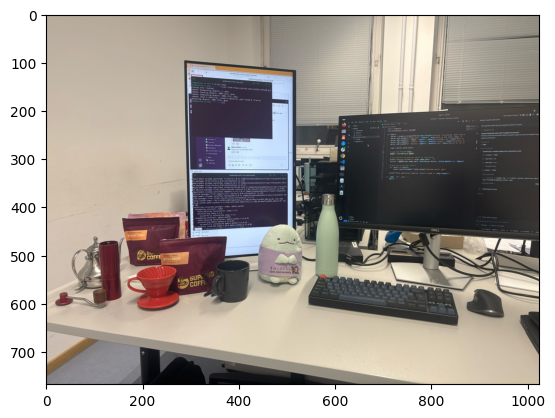

In [44]:
image = Image.open(input_image_path)
image.save(os.path.join(output_dir, f'{image_name}.png'))
plt.imshow(image)

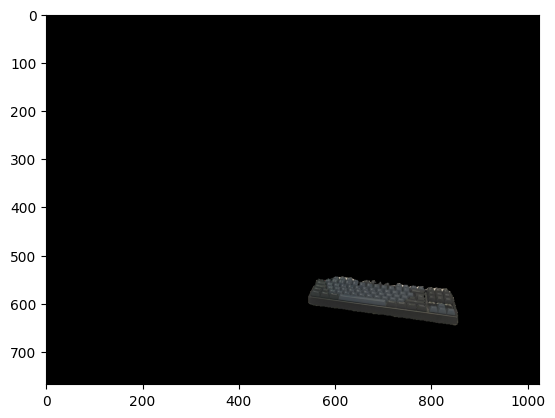

In [48]:
with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
    predictor.set_image(image)
    masks, _, _ = predictor.predict(point_coords=np.array([[800, 600]]), point_labels=[1])
masks = masks.mean(axis=0) > 0
cropped_image = np.array(image.copy())
cropped_image[~masks] = 0.0
plt.imshow(cropped_image)
mask_img_array = (masks * 255).astype(np.uint8)
img = Image.fromarray(mask_img_array, mode='L')
# 4. Save to disk
img.save(os.path.join(output_dir, "foreground.png"))

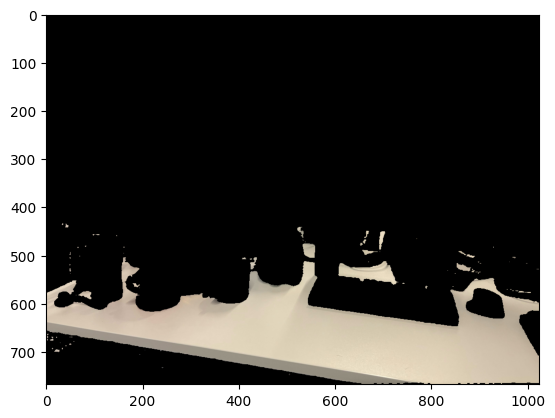

In [49]:
with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
    predictor.set_image(image)
    masks, _, _ = predictor.predict(point_coords=np.array([[500, 600]]), point_labels=[1])
masks = masks.mean(axis=0) > 0
cropped_image = np.array(image.copy())
cropped_image[~masks] = 0.0
plt.imshow(cropped_image)
mask_img_array = (masks * 255).astype(np.uint8)
img = Image.fromarray(mask_img_array, mode='L')
# 4. Save to disk
img.save(os.path.join(output_dir, "xy_plane.png"))

In [50]:
caption = "keyboard"


with open(os.path.join(output_dir, "caption.txt"), "w") as file:
    file.write(caption)